In [1]:
%load_ext autoreload

import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml

from portfolio_price_discrete_PPO_sharpe.enviroment import Stock_Env as ppo_stock_env
from portfolio_price_discrete_PPO_sharpe.agent import PPO as ppo_agent
from portfolio_price_discrete_PPO_sharpe.run_monthly import eval_env as ppo_eval_env

from portfolio_price_discrete_SAC_sharpe.enviroment import Stock_Env as sac_stock_env
from portfolio_price_discrete_SAC_sharpe.agent import DiscreteSACAgent as sac_agent
from portfolio_price_discrete_SAC_sharpe.run_monthly import eval_env as sac_eval_env


from portfolio_price_discrete_rebal_step_1m_concat_sharpe.enviroment import Stock_Env as grpo_stock_env
from portfolio_price_discrete_rebal_step_1m_concat_sharpe.agent import PPO as grpo_agent
from portfolio_price_discrete_rebal_step_1m_concat_sharpe.grpo_monthly import test_grpo as grpo_eval_env

Current working directory: /workspace
Current working directory: /workspace
Current working directory: /workspace


In [2]:
ppo_worst_seed = 50
ppo_best_seed = 25
start_date =  "2019-01-01"
end_data = "2024-12-31"

sac_worst_seed = 39
sac_best_seed = 50

grpo_worst_seed = 42
grpo_best_seed = 33

In [3]:
index_train_path = "./data/train_v3.csv"
index_test_path = "./data/test_v3.csv"
future_train_path = "./data/future_train_v3.csv"
future_test_path = "./data/future_test_v3.csv"
test_pt = "./data/portfolio_price/concat_portfolio_test_monthly_v1.pt"
with open("./portfolio_price_discrete_PPO_v1/config/test_config.yaml", "r") as f:
    ppo_config = yaml.safe_load(f)
    
device = torch.device(ppo_config.get("device", "cuda:0"))
ppo_config["device"] = device

index_train_for_valid = pd.read_csv(index_train_path, index_col=0)
index_test_df = pd.read_csv(index_test_path, index_col=0)

index_test_all_df = pd.concat([index_train_for_valid, index_test_df], axis=0)
index_test_all_df.reset_index(drop=True, inplace=True)
index_test_all_df.set_index("date", inplace=True)

future_train_for_valid = pd.read_csv(future_train_path, index_col=0)
future_test_df = pd.read_csv(future_test_path, index_col=0)
future_test_all_df = pd.concat([future_train_for_valid, future_test_df], axis=0)
future_test_all_df.reset_index(drop=True, inplace=True)
future_test_all_df.set_index("date", inplace=True)


test_tensor = torch.load(test_pt, map_location=device)
traj_len ="1m"
update_interval = ppo_config["update_interval_map"].get(traj_len, 60)
ppo_config["update_interval"] = update_interval
ppo_config["batch_samples"] = ppo_config["batch_samples"].get(traj_len, 5)
ppo_config["TRADE_START_DATE"] =start_date
ppo_config["TRADE_END_DATE"] = end_data
ppo_env = ppo_stock_env(config=ppo_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)
    

/tmp/ipykernel_1085664/596938847.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_tensor = torch.load(test_pt, map_location=device)


In [4]:
with open("./portfolio_price_discrete_rebal_step_1m_concat_asset/config/test_config.yaml", "r") as f:
    grpo_config = yaml.safe_load(f)

In [5]:
update_interval = grpo_config["update_interval_map"].get(traj_len, 60)
grpo_config["update_interval"] = update_interval
grpo_config["batch_samples"] = grpo_config["batch_samples"].get(traj_len, 5)
grpo_config["TRADE_START_DATE"] = "2019-01-01"
grpo_config["TRADE_END_DATE"] = "2024-12-31"
grpo_env = grpo_stock_env(config=grpo_config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)


In [6]:
worst_grpo_agent = grpo_agent(grpo_env, eval=True)
worst_grpo_model_path =  f"./portfolio_price_discrete_rebal_step_1m_concat_asset/model/good result/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu100_num_group16_num_steps10_reward_cond_sharpe_seed{grpo_worst_seed}_grpo_model.pth"
worst_grpo_agent.load(worst_grpo_model_path)
grpo_worst_model_return, grpo_worst_strategy_returns, grpo_worst_weight_rebal, grpo_worst_strategy_weights = grpo_eval_env(grpo_env, worst_grpo_agent)


best_grpo_agent = grpo_agent(grpo_env, eval=True)
best_grpo_model_path =  f"./portfolio_price_discrete_rebal_step_1m_concat_asset/model/good result/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu100_num_group16_num_steps10_reward_cond_sharpe_seed{grpo_best_seed}_grpo_model.pth"
best_grpo_agent.load(best_grpo_model_path)
grpo_best_model_return, grpo_best_strategy_returns, grpo_best_weight_rebal, grpo_best_strategy_weights = grpo_eval_env(grpo_env, best_grpo_agent)

/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

./portfolio_price_discrete_rebal_step_1m_concat_asset/model/good result/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu100_num_group16_num_steps10_reward_cond_sharpe_seed42_grpo_model.pth loaded.
76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23


/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/agent.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state = torch.load(model_path, map_location=s

./portfolio_price_discrete_rebal_step_1m_concat_asset/model/good result/final_1m_actor_lr1e-06_clip_grad1_epslion_0.2batch_sample_2048_mu100_num_group16_num_steps10_reward_cond_sharpe_seed33_grpo_model.pth loaded.
76
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021-02-23


In [7]:
strategy_return = pd.DataFrame(grpo_best_strategy_returns)

In [8]:
strategy_return = strategy_return[['risk_parity', 'min_var', 'max_sharpe', 'paa']]

In [2]:
model_return = pd.read_csv("/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/result/grpo_del/0.003_total_del_avg.csv", index_col=0)

In [4]:
eqaul_return = pd.read_csv("/workspace/portfolio_price_discrete_rebal_step_1m_concat_sharpe/result/benchmark_del/0.003_benchmark.csv", index_col=0)

In [7]:
total_return = pd.concat([model_return, eqaul_return], axis=1)

In [10]:
total_return

,GRPO,PPO,SAC,risk_parity,min_var,max_sharpe,paa,equal_strategy,equal_asset_weight
2019-01-30,0.021799,-0.016721,-0.014740,0.060012,0.041212,-0.079102,-0.016721,0.001350,0.054127
2019-02-28,0.020955,0.020955,0.019843,0.020955,0.012108,0.026901,0.012351,0.018079,0.019223
2019-03-28,-0.007319,-0.005156,-0.008855,-0.005156,-0.010123,-0.008995,-0.011004,-0.008819,-0.003245
2019-04-26,0.023269,0.027753,0.019544,0.027753,0.005332,0.021694,0.021245,0.019006,0.027546
2019-05-24,-0.025046,-0.027919,-0.027554,-0.027919,-0.013556,-0.030867,-0.034561,-0.026726,-0.031184
...,...,...,...,...,...,...,...,...,...
2024-09-20,0.007695,-0.014056,0.003555,0.030146,0.041552,0.007695,-0.025107,0.013572,0.034196
2024-10-18,0.026079,0.012836,0.013755,0.007070,0.013938,0.026079,0.014277,0.015341,0.001142
2024-11-15,-0.006021,-0.003139,-0.015770,-0.043323,-0.028632,-0.006021,0.006907,-0.017767,-0.016485
2024-12-16,0.065300,0.058342,0.053909,0.018710,0.022765,0.065300,0.083412,0.047547,0.037941


In [11]:
def convert_to_log_returns(returns):
    """
    단순 수익률 데이터를 로그 수익률로 변환합니다.
    log(1 + r_t)
    """
    returns = np.asarray(returns, dtype=np.float64)
    return np.log1p(returns)  # np.log1p(x) = log(1 + x), 정확도 ↑

def calculate_log_cumulative_returns(returns):
    """
    누적 로그 수익률 시계열을 반환합니다.
    """
    log_returns = convert_to_log_returns(returns)
    return np.cumsum(log_returns)  # 시계열 형태로 반환


def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


def calculate_downside_deviation(returns, threshold=0.0, annual_factor=252, annualize=True):
    downside = np.minimum(returns - threshold, 0)
    dd = np.sqrt(np.mean(downside ** 2))
    return dd * np.sqrt(annual_factor) if annualize else dd


def calculate_annualized_sortino_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return = annual_return - risk_free_rate
    downside_dev = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    return excess_return / downside_dev if downside_dev != 0 else 0.0


def calculate_calmar_ratio(returns, annual_factor=252):
    """
    Calmar Ratio = Annualized Return / Maximum Drawdown
    """
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    max_drawdown = calculate_max_drawdown(returns)
    
    return  (annual_return) / max_drawdown if max_drawdown != 0 else 0.0  # MDD가 0이면 0 반환


def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    if excess_return == 0:
        sign = 1
    else:
        sign = excess_return / abs(excess_return)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    # 연환산 수익률과 표준편차
    modified_sharpe =  excess_return / (annual_std_dev ** sign)  if annual_std_dev != 0 else 0.0
    return modified_sharpe



def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)
    sortino_ratio = calculate_annualized_sortino_ratio(returns, risk_free_rate, annual_factor)
    downside_deviation = calculate_downside_deviation(returns, threshold=0.0, annual_factor=annual_factor)
    # Calmar Ratio 계산
    calmar_ratio = calculate_calmar_ratio(returns, annual_factor)
    log_cumulative_return = np.sum(np.log1p(returns))

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Log Cumulative Return': log_cumulative_return,

        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd,
        'Downside Deviation': downside_deviation,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np




In [12]:
# total_return.to_csv("subperiod_total_average.csv")

In [13]:
metrics_summary = get_performance_summary(
    total_return,
    annual_factor=12,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Log Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD,Downside Deviation,Sortino Ratio,Calmar Ratio
GRPO,2.006449,1.100760,0.189823,0.160825,1.180306,0.194461,0.078354,2.422629,0.976146
PPO,1.454905,0.898088,0.152350,0.150853,1.009921,0.205702,0.098195,1.551502,0.740635
SAC,0.757038,0.563630,0.093074,0.149851,0.621111,0.285355,0.100780,0.923535,0.326170
risk_parity,0.505980,0.409444,0.066785,0.147400,0.453082,0.254201,0.103136,0.647539,0.262724
min_var,1.089501,0.736925,0.123396,0.114088,1.081589,0.193105,0.066591,1.853058,0.639013
max_sharpe,0.502133,0.406886,0.066354,0.210630,0.315025,0.496835,0.140345,0.472792,0.133553
paa,0.808199,0.592332,0.098039,0.172922,0.566957,0.304134,0.115535,0.848564,0.322355
equal_strategy,0.757471,0.563876,0.093117,0.135742,0.685985,0.228384,0.092061,1.011469,0.407721
equal_asset_weight,0.492634,0.400542,0.065286,0.157241,0.415198,0.313931,0.110546,0.590577,0.207963


In [14]:
metrics_summary.T

,GRPO,PPO,SAC,risk_parity,min_var,max_sharpe,paa,equal_strategy,equal_asset_weight
Cumulative Return,2.006449,1.454905,0.757038,0.505980,1.089501,0.502133,0.808199,0.757471,0.492634
Log Cumulative Return,1.100760,0.898088,0.563630,0.409444,0.736925,0.406886,0.592332,0.563876,0.400542
Annual Return,0.189823,0.152350,0.093074,0.066785,0.123396,0.066354,0.098039,0.093117,0.065286
Volatility,0.160825,0.150853,0.149851,0.147400,0.114088,0.210630,0.172922,0.135742,0.157241
Sharpe Ratio,1.180306,1.009921,0.621111,0.453082,1.081589,0.315025,0.566957,0.685985,0.415198
MDD,0.194461,0.205702,0.285355,0.254201,0.193105,0.496835,0.304134,0.228384,0.313931
Downside Deviation,0.078354,0.098195,0.100780,0.103136,0.066591,0.140345,0.115535,0.092061,0.110546
Sortino Ratio,2.422629,1.551502,0.923535,0.647539,1.853058,0.472792,0.848564,1.011469,0.590577
Calmar Ratio,0.976146,0.740635,0.326170,0.262724,0.639013,0.133553,0.322355,0.407721,0.207963


In [15]:
total_return

,GRPO,PPO,SAC,risk_parity,min_var,max_sharpe,paa,equal_strategy,equal_asset_weight
2019-01-30,0.021799,-0.016721,-0.014740,0.060012,0.041212,-0.079102,-0.016721,0.001350,0.054127
2019-02-28,0.020955,0.020955,0.019843,0.020955,0.012108,0.026901,0.012351,0.018079,0.019223
2019-03-28,-0.007319,-0.005156,-0.008855,-0.005156,-0.010123,-0.008995,-0.011004,-0.008819,-0.003245
2019-04-26,0.023269,0.027753,0.019544,0.027753,0.005332,0.021694,0.021245,0.019006,0.027546
2019-05-24,-0.025046,-0.027919,-0.027554,-0.027919,-0.013556,-0.030867,-0.034561,-0.026726,-0.031184
...,...,...,...,...,...,...,...,...,...
2024-09-20,0.007695,-0.014056,0.003555,0.030146,0.041552,0.007695,-0.025107,0.013572,0.034196
2024-10-18,0.026079,0.012836,0.013755,0.007070,0.013938,0.026079,0.014277,0.015341,0.001142
2024-11-15,-0.006021,-0.003139,-0.015770,-0.043323,-0.028632,-0.006021,0.006907,-0.017767,-0.016485
2024-12-16,0.065300,0.058342,0.053909,0.018710,0.022765,0.065300,0.083412,0.047547,0.037941


In [16]:
zero_row = pd.DataFrame([[0]*total_return.shape[1]], columns=total_return.columns)


In [17]:
zero_row.index = ["2019-01-01"]

In [18]:
total_return = pd.concat([zero_row, total_return])


In [19]:
total_return.columns

Index(['GRPO', 'PPO', 'SAC', 'risk_parity', 'min_var', 'max_sharpe', 'paa',
       'equal_strategy', 'equal_asset_weight'],
      dtype='object')

In [20]:
rename_dict = {
    'risk_parity': 'RP',
    'min_var': 'MV',
    'max_sharpe': 'MS',
    'paa': 'PAA',
    'equal_strategy': 'ES',
    'equal_asset_weight' : 'EA'
}

In [21]:
total_return.rename(columns=rename_dict, inplace=True)

In [22]:
total_return.columns

Index(['GRPO', 'PPO', 'SAC', 'RP', 'MV', 'MS', 'PAA', 'ES', 'EA'], dtype='object')

In [23]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
#                                      title='Cumulative Returns',
#                                      y_range=(0.0, 5),
#                                      test_start_date=None):

#     plt.figure(figsize=(15, 20))

#     # 누적 로그 수익률 계산
#     cum_returns = np.log1p(returns_df).cumsum()

#     # 강조할 전략
#     bold_strategies = ['grpo_best', 'grpo_worst']

#     # 더 구분되는 색상 팔레트 사용
#     color_map = {
#         'SAC': '#1f77b4',          # Blue
#         'Min Var': '#ff7f0e',              # Orange
#         'Max Sharpe': '#2ca02c',           # Green
#         'PAA': '#e377c2',                  # Red
#         'Equal Strategy': '#8c564b',   # Brown
#         'Risk Parity': '#bcbd22',            # Olive
#         'Equal Asset Weight': '#7f7f7f',            # Gray
#         'GRPO': '#000000',            # Black (굵은)
#         'PPO': '#ff0000',           # Bright Red (굵은)
#     }

#     for col in cum_returns.columns:
#         linewidth = 3.5 if col in bold_strategies else 2.0
#         color = color_map.get(col, None)

#         plt.plot(
#             cum_returns.index,
#             cum_returns[col],
#             label=col,
#             linewidth=linewidth,
#             color=color
#         )

#     # x축 날짜 형식

#     plt.xticks(rotation=45, fontsize=14)

#     if test_start_date:
#         plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

#     plt.ylim(y_range)
#     plt.yticks(fontsize=18)
#     plt.ylabel('Log Cumulative Returns', fontsize=18)

#     plt.xlabel('Date', fontsize=16)
#     plt.title(title, fontsize=20)
#     plt.legend(loc='upper left', fontsize=16, ncol=2)
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()


In [24]:
import matplotlib.dates as mdates


In [25]:
def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
                                     title='Cumulative Returns',
                                     y_range=(0.0, 5),
                                     test_start_date=None):

    plt.figure(figsize=(7, 4.5))  # A4 반절

    # datetime index 보장
    returns_df.index = pd.to_datetime(returns_df.index)

    cum_returns = np.log1p(returns_df).cumsum()

    bold_strategies = ['GRPO', 'PPO', 'SAC']
    color_map = {
        'SAC': '#1f77b4',
        'MV': '#ff7f0e',
        'MS': '#2ca02c',
        'PAA': '#e377c2',
        'ES': '#8c564b',
        'RP': '#bcbd22',
        'EA': '#7f7f7f',
        'GRPO': '#000000',
        'PPO': '#ff0000',
    }

    for col in cum_returns.columns:
        linewidth = 2.0
        color = color_map.get(col, None)
        plt.plot(cum_returns.index, cum_returns[col], label=col,
                 linewidth=linewidth, color=color)

    # x축 날짜 포맷 간격 조정
    ax = plt.gca()

    tick_idx = returns_df.index[::3]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_idx.strftime('%Y-%m'), rotation=45, fontsize=9)
    # ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, fontsize=10)

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.ylim(y_range)
    plt.yticks(fontsize=10)
    plt.ylabel('Log Cumulative Returns', fontsize=10)
    plt.xlabel('Date', fontsize=10)
    # plt.title(title, fontsize=15)

    # ✅ 범례를 바깥 오른쪽에 배치
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.42),  # ↘ 더 아래
        ncol=3,
        fontsize=9,
        frameon=False
    )
    # plt.grid(True)
    plt.subplots_adjust(bottom=0.4)  # 하단 여백 확보
    plt.savefig("figure/log_cum_return_del_asset.png", transparent=True, dpi=600, bbox_inches='tight')

    plt.show()


In [26]:
np.log1p(total_return).cumsum()

,GRPO,PPO,SAC,RP,MV,MS,PAA,ES,EA
2019-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-01-30,0.021565,-0.016862,-0.014850,0.058280,0.040386,-0.082406,-0.016862,0.001349,0.052713
2019-02-28,0.042303,0.003876,0.004799,0.079018,0.052421,-0.055861,-0.004586,0.019267,0.071753
2019-03-28,0.034957,-0.001293,-0.004095,0.073849,0.042246,-0.064897,-0.015651,0.010408,0.068503
2019-04-26,0.057959,0.026082,0.015260,0.101224,0.047564,-0.043434,0.005371,0.029236,0.095676
...,...,...,...,...,...,...,...,...,...
2024-09-20,1.041295,0.839727,0.533522,0.459849,0.753471,0.345382,0.486117,0.538022,0.401913
2024-10-18,1.067040,0.852481,0.547183,0.466894,0.767313,0.371127,0.500293,0.553247,0.403054
2024-11-15,1.061001,0.849338,0.531287,0.422605,0.738263,0.365088,0.507176,0.535320,0.386432
2024-12-16,1.124257,0.906041,0.583793,0.441142,0.760772,0.428344,0.587291,0.581771,0.423671


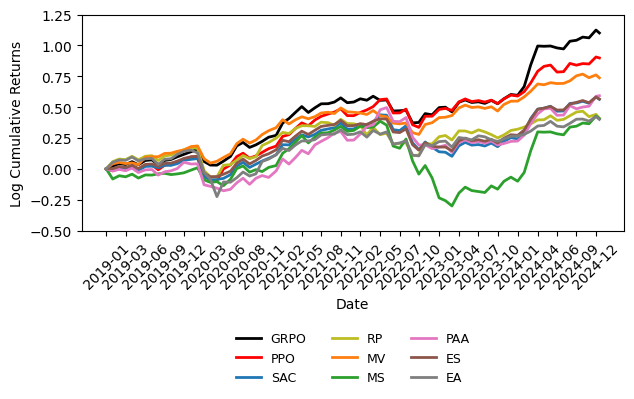

In [27]:
plot_cumulative_returns_from_df(total_return, title="Monthly Log Cumulative Comparison", y_range=(-0.5, 1.25))


In [28]:
def plot_cumulative_returns_from_df(returns_df: pd.DataFrame,
                                     title='Cumulative Returns',
                                     y_range=(0.0, 5),
                                     test_start_date=None):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import numpy as np

    # 적절한 사이즈 (A4 절반 수준)
    plt.figure(figsize=(6, 4))

    # 누적 로그 수익률 계산
    cum_returns = np.log1p(returns_df).cumsum()

    bold_strategies = ['GRPO', 'PPO']  # 대소문자 확인
    color_map = {
        'GRPO': 'black',
        'PPO': 'red',
        'SAC': 'skyblue',
        'Equal Strategy': 'brown',
        'Equal Asset Weight': 'gray',
        'Risk Parity': 'yellowgreen',
        'Min Var': 'orange',
        'Max Sharpe': 'green',
        'PAA': 'violet',
    }

    for col in cum_returns.columns:
        linewidth = 2.5 if col in bold_strategies else 1.5
        plt.plot(
            cum_returns.index,
            cum_returns[col],
            label=col,
            linewidth=linewidth,
            color=color_map.get(col, None)
        )

    # x축 날짜 간격과 포맷 정리
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 3개월 간격
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, fontsize=10)

    # 범례 위치 조정
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)

    plt.ylim(y_range)
    plt.yticks(fontsize=10)
    plt.ylabel('Log Cumulative Returns', fontsize=12)
    plt.xlabel('Date', fontsize=11)
    plt.title(title, fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
df = total_return.iloc[1:]
# long-form으로 변환

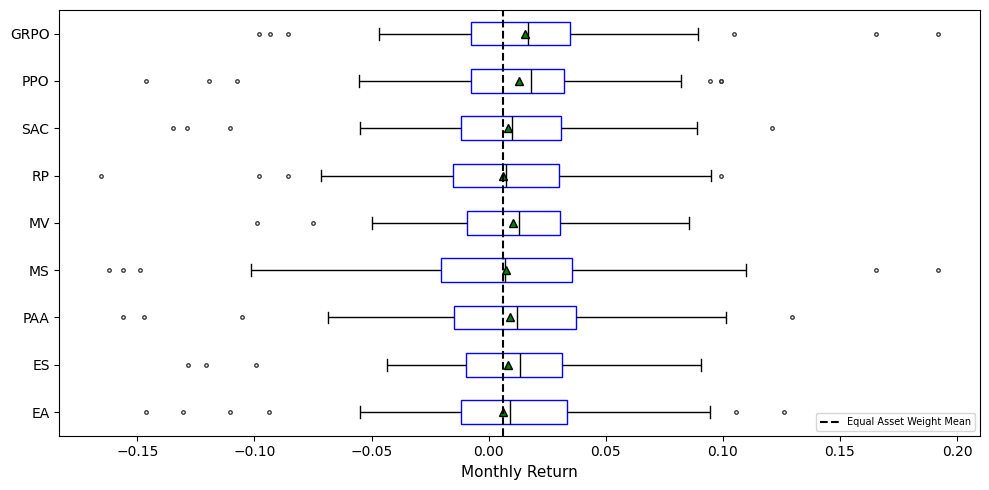

In [30]:
# 예시용 DataFrame (실제 df로 대체)
# df = pd.DataFrame({...})

# 컬럼 순서 (원하는 순서로)
strategy_order = ['GRPO', 'PPO', 'SAC',
         'RP', 'MV', 'MS',
         'PAA', 'ES', 'EA']
# 박스플롯 스타일 설정
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[strategy_order],
    orient='h',
    width=0.5,
    fliersize=2.5,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "black",
        "markersize": 6
    },
    boxprops=dict(facecolor='white', edgecolor='blue'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black'),
)

# plt.title('Monthly Return Distribution', fontsize=14)
plt.xlabel('Monthly Return', fontsize=11)
plt.ylabel('')
# plt.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.7)

# 수평 벤치마크 라인 추가 (예: SP500 평균 기준)
benchmark_value = df['EA'].mean()
plt.axvline(
    x=benchmark_value,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Equal Asset Weight Mean',
    zorder=5
)

plt.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig("figure/Monthly_return_distribution_del_asset.png", transparent=True, dpi=600, bbox_inches='tight')

plt.show()


In [56]:
imp = total_df[["equal_strategy", "equal_asset_weight"]]

In [61]:
imp.to_csv("./portfolio_price_discrete_rebal_step_1m_concat_asset/result/equal_strategy.csv")